# geopandas I: datos vectoriales

[![Abrir en Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gf0657-programacionsig/2026-ii/blob/main/contenidos/iv-procesamiento-datos-geoespaciales/17-geopandas-datos-vectoriales.ipynb)

## Trabajo previo

### Lecturas

Antes de la clase, revise las siguientes lecturas, en inglés. La introducción de la documentación oficial presenta las estructuras de datos de geopandas y sus operaciones básicas; la lección de Kaggle construye un primer mapa y es breve e interactiva.

GeoPandas developers. (s. f.-a). Introduction to GeoPandas. En *GeoPandas documentation*. Recuperado el 4 de octubre de 2026, de https://geopandas.org/en/stable/getting_started/introduction.html
\
\
Kaggle. (s. f.). Your first map. En *Geospatial analysis*. Kaggle Learn. Recuperado el 4 de octubre de 2026, de https://www.kaggle.com/code/alexisbcook/your-first-map

### Otros recursos

La [guía del usuario de geopandas](https://geopandas.org/en/stable/docs/user_guide.html) es la referencia permanente de esta sección: en particular, las páginas sobre [estructuras de datos](https://geopandas.org/en/stable/docs/user_guide/data_structures.html), [lectura y escritura de archivos](https://geopandas.org/en/stable/docs/user_guide/io.html), [mapas](https://geopandas.org/en/stable/docs/user_guide/mapping.html), [mapas interactivos](https://geopandas.org/en/stable/docs/user_guide/interactive_mapping.html) y [sistemas de referencia de coordenadas](https://geopandas.org/en/stable/docs/user_guide/projections.html). El curso [Geospatial analysis](https://www.kaggle.com/learn/geospatial-analysis) de Kaggle cubre con ejercicios los temas de esta y la siguiente semana.

## Introducción

Este cuaderno abre la serie *geopandas*, que pone en práctica los conceptos de la lección [Datos geoespaciales](https://gf0657-programacionsig.github.io/2026-ii/datos-geoespaciales/): geometrías vectoriales, sistemas de referencia de coordenadas (SRC) y formatos de archivo. La serie *pandas* terminó con una tabla por cantón: población, viviendas, área, densidad. Lo que faltaba era el mapa. Aquí los 82 cantones del INEC se encuentran con sus polígonos, publicados por el [Instituto Geográfico Nacional (IGN)](https://www.snitcr.go.cr/), y las preguntas de las semanas anteriores (¿cuáles cantones son los más densos?, ¿dónde crece y dónde decrece la población?) se responden con mapas.

[geopandas](https://geopandas.org/) extiende pandas con un tipo de columna nuevo, la **geometría**, y con las operaciones que esa columna hace posibles: dibujar mapas, reproyectar, medir, y, en la parte II, relacionar capas por su posición. Sus dos estructuras son la **GeoSeries**, una columna de geometrías (puntos, líneas o polígonos de shapely), y el **GeoDataFrame**, un DataFrame con una GeoSeries como **columna de geometría activa** (figura 1). Todo lo aprendido de pandas aplica sin cambios: `head()`, el filtrado booleano, `sort_values()`, `groupby()`, `merge()`. Para leer y escribir archivos, geopandas se apoya en [pyogrio](https://pyogrio.readthedocs.io/) y GDAL; para las geometrías, en [shapely](https://shapely.readthedocs.io/); para los SRC, en [pyproj](https://pyproj4.github.io/pyproj/); para los mapas, en matplotlib y en [folium](https://python-visualization.github.io/folium/).

<figure style="text-align: center;">
  <img
    src="https://raw.githubusercontent.com/gf0657-programacionsig/2026-ii/main/contenidos/iv-procesamiento-datos-geoespaciales/img/geodataframe.png"
    alt="Esquema de un GeoDataFrame"
    width="600"
  >
  <figcaption><strong>Figura 1</strong>. Un GeoDataFrame es un DataFrame con una columna de geometrías (GeoSeries). Fuente: GeoPandas developers (s. f.-a).</figcaption>
</figure>

Los datos son las capas del IGN de provincias, cantones y aeródromos, preparadas para el curso en el directorio [`datos/ign/`](https://github.com/gf0657-programacionsig/2026-ii/tree/main/datos/ign) del repositorio (la capa de cantones tiene la división territorial de 2011, la misma de los datos del INEC), y los CSV del INEC de la sección anterior.

Como todos los cuadernos del curso, puede ejecutarse en la nube, con la insignia "Abrir en Google Colab", o localmente, en [Visual Studio Code](https://gf0657-programacionsig.github.io/2026-ii/vscode/) con el ambiente `geopython` como kernel. Colab trae geopandas y folium instalados; la biblioteca [mapclassify](https://pysal.org/mapclassify/), que se usa en una subsección sobre clasificación, está en `geopython` pero no en Colab, donde se instala con `!pip install mapclassify` cuando haga falta. El archivo `.ipynb` puede descargarse con el botón de descarga (ícono de flecha hacia abajo) en la parte superior de la página del cuaderno, en el sitio web del curso.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm

# Direcciones de los directorios de datos en el repositorio del curso
DATOS_IGN = "https://raw.githubusercontent.com/gf0657-programacionsig/2026-ii/main/datos/ign"
DATOS_INEC = "https://raw.githubusercontent.com/gf0657-programacionsig/2026-ii/main/datos/inec"

# Colores de los cuadernos anteriores
AZUL = "#1F77B4"
NARANJA = "#D97B1B"

print("geopandas", gpd.__version__)

geopandas 1.1.4


## Carga de una capa

`gpd.read_file()` lee cualquier formato vectorial que GDAL conozca (GeoPackage, Shapefile, GeoJSON y [muchos más](https://gdal.org/en/stable/drivers/vector/)) desde una ruta local o desde una URL, y retorna un GeoDataFrame. Por convención, geopandas se importa como `gpd`. La capa de cantones del IGN:

In [2]:
# Capa de cantones del IGN (división territorial de 2011), en formato GeoPackage
cantones = gpd.read_file(DATOS_IGN + "/cantones-2011.gpkg")

cantones.head()

,codigo_provincia,provincia,codigo_canton,canton,geometry
0,1,San José,101,San José,"MULTIPOLYGON (((481030.259 1102633.076, 481510..."
1,1,San José,102,Escazú,"MULTIPOLYGON (((479844.85 1102669.496, 479982...."
2,1,San José,103,Desamparados,"MULTIPOLYGON (((494091.148 1094936.709, 494448..."
3,1,San José,104,Puriscal,"MULTIPOLYGON (((455732.068 1095962.382, 456519..."
4,1,San José,105,Tarrazú,"MULTIPOLYGON (((501118.499 1074475.486, 502323..."


Se ve como un DataFrame, y lo es, con una columna más: `geometry`, que contiene un multipolígono por cantón, impreso en WKT. Tres propiedades que no existen en pandas describen la parte geoespacial:

In [3]:
# Tipo del objeto, SRC y tipos de geometría
print(type(cantones))
print(cantones.shape)
print(cantones.crs)
print(cantones.geom_type.value_counts())

<class 'geopandas.geodataframe.GeoDataFrame'>
(82, 5)
EPSG:5367
MultiPolygon    82
Name: count, dtype: int64


- `crs` es el **sistema de referencia de coordenadas** de la capa: CR05 / CRTM05, el oficial de Costa Rica, con coordenadas en metros.
- `geom_type` es una Series con el tipo de geometría de cada fila. Aquí todas son multipolígonos, aunque la mayoría de los cantones tienen un solo cuerpo: el IGN usa el tipo "multi" para toda la capa, lo que permite representar los que sí tienen islas, como Puntarenas.
- `geometry` es la columna de geometría activa, una GeoSeries. Una geometría individual es un objeto de shapely, que Jupyter dibuja:

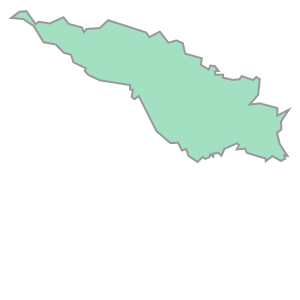

In [4]:
# La geometría del cantón de la primera fila
cantones.geometry[0]

In [5]:
# Nombre, SRC y área (en las unidades del SRC: m²) de esa geometría
print(cantones.loc[0, "canton"])
print(cantones.geometry[0].area)

San José
44718369.00930649


La capa de aeródromos es de puntos y la de provincias, de polígonos; las tres están en el mismo SRC:

In [6]:
# Capas de provincias y de aeródromos
provincias = gpd.read_file(DATOS_IGN + "/provincias.gpkg")
aerodromos = gpd.read_file(DATOS_IGN + "/aerodromos.gpkg")

print(provincias.shape, provincias.geom_type.unique().tolist(), provincias.crs.to_epsg())
print(aerodromos.shape, aerodromos.geom_type.unique().tolist(), aerodromos.crs.to_epsg())
aerodromos.head()

(7, 3) ['MultiPolygon'] 5367
(119, 3) ['Point'] 5367


,nombre,codigo_distrito,geometry
0,Aeródromo Barra de Tortuguero,70206,POINT (553033.457 1168803.442)
1,Aeródromo Barra de Colorado,70206,POINT (545315.015 1190833.369)
2,Campo de Aterrizaje,60702,POINT (571056.393 929067.32)
3,Campo de Aterrizaje,60702,POINT (564354.142 932347.956)
4,Campo de Aterrizaje,60704,POINT (598946.798 932528.285)


`crs.to_epsg()` retorna el código EPSG, más cómodo de comparar que el nombre completo. En la lección anterior se mencionó que geopandas también puede leer capas publicadas como servicios WFS; en el bloque siguiente se muestra cómo, con la capa de cantones del SNIT, pero el resto del cuaderno usa las copias del repositorio, que no dependen de la disponibilidad del servicio ni de la red del aula:

```python
# Lectura de una capa WFS del SNIT (no se ejecuta en clase)
url = (
    "https://geos.snitcr.go.cr/be/IGN_5_CO/wfs?service=WFS&version=2.0.0&request=GetFeature"
    "&typeName=IGN_5_CO:limitecantonal_5k&outputFormat=application/json"
)
cantones_wfs = gpd.read_file(url)
```

*Ejercicios de esta sección: 1, en la sección de ejercicios al final del cuaderno.*

## Un GeoDataFrame es un DataFrame

Todas las operaciones de pandas funcionan igual, y el resultado conserva la geometría. Los cantones de Heredia, ordenados por nombre:

In [7]:
# Filtrado booleano y ordenamiento, como en pandas
heredia = cantones[cantones["provincia"] == "Heredia"].sort_values("canton")

print(type(heredia))
heredia

<class 'geopandas.geodataframe.GeoDataFrame'>


,codigo_provincia,provincia,codigo_canton,canton,geometry
45,4,Heredia,402,Barva,"MULTIPOLYGON (((486302.057 1120517.303, 486889..."
50,4,Heredia,407,Belén,"MULTIPOLYGON (((480648.031 1106324.568, 481219..."
51,4,Heredia,408,Flores,"MULTIPOLYGON (((483152.463 1107874.12, 484129...."
44,4,Heredia,401,Heredia,"MULTIPOLYGON (((485819.199 1107392.204, 486565..."
49,4,Heredia,406,San Isidro,"MULTIPOLYGON (((495645.165 1112504.421, 496109..."
52,4,Heredia,409,San Pablo,"MULTIPOLYGON (((491777.674 1106643.601, 491963..."
48,4,Heredia,405,San Rafael,"MULTIPOLYGON (((490951.609 1119092.398, 491273..."
47,4,Heredia,404,Santa Bárbara,"MULTIPOLYGON (((482367.011 1123262.055, 482761..."
46,4,Heredia,403,Santo Domingo,"MULTIPOLYGON (((497196.224 1107491.4, 497338.0..."
53,4,Heredia,410,Sarapiquí,"MULTIPOLYGON (((496954.941 1193308.362, 497719..."


La diferencia aparece al pedir un mapa: el método `plot()`, que en pandas dibuja un gráfico de las columnas numéricas, en geopandas dibuja las **geometrías**:

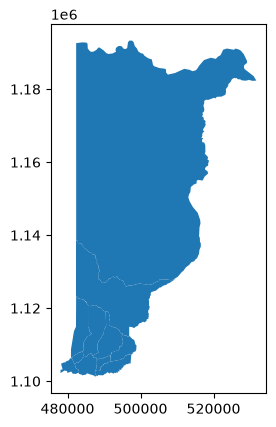

In [8]:
# Mapa rápido de los cantones de Heredia
heredia.plot()
plt.show()

Los ejes muestran las coordenadas del SRC: metros de CRTM05. Con eso basta para explorar; para comunicar, el mapa se construye con el mismo patrón `fig, ax = plt.subplots()` de la [parte III](https://gf0657-programacionsig.github.io/2026-ii/pandas-graficos-matplotlib/) de la serie *pandas*.

*Ejercicios de esta sección: 2, en la sección de ejercicios al final del cuaderno.*

## Mapas estáticos

`plot()` acepta los argumentos de matplotlib para el relleno (`color`), el borde (`edgecolor`, `linewidth`) y la transparencia (`alpha`), y dibuja sobre el `ax` que se le indique, lo que permite **superponer capas**: cada llamada agrega una capa al mismo mapa. Los cantones con los límites provinciales encima:

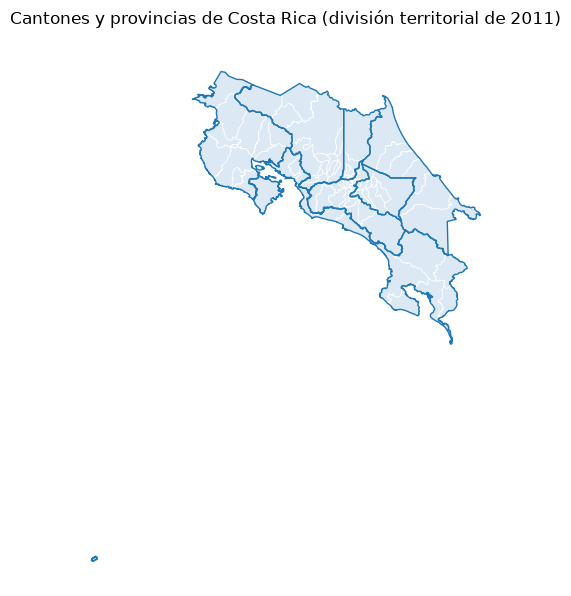

In [9]:
# Cantones y provincias de Costa Rica
fig, ax = plt.subplots(figsize=(9, 7))

cantones.plot(ax=ax, color="#DCE9F5", edgecolor="white", linewidth=0.5)
provincias.boundary.plot(ax=ax, color=AZUL, linewidth=1)

ax.set_title("Cantones y provincias de Costa Rica (división territorial de 2011)")
ax.set_axis_off()  # en un mapa de referencia, las coordenadas de los ejes no aportan

plt.show()

`boundary` es una propiedad de la GeoSeries que convierte los polígonos en sus líneas de contorno: así las provincias se dibujan solo como límites, sin relleno que tape los cantones.

El país quedó pequeño en la figura por el punto de la esquina inferior izquierda: la **Isla del Coco**, parte del cantón de Puntarenas, a más de 500 km de la costa. Como la extensión del mapa se ajusta a todas las geometrías, la isla obliga a dibujar un enorme espacio de océano. Para los mapas nacionales, la solución es fijar los límites de los ejes a la parte continental, con `set_xlim()` y `set_ylim()`, en las unidades del SRC (metros de CRTM05); los límites se guardan en dos constantes para reutilizarlos en el resto del cuaderno. Los puntos se agregan como cualquier otra capa, con `markersize` para el tamaño:

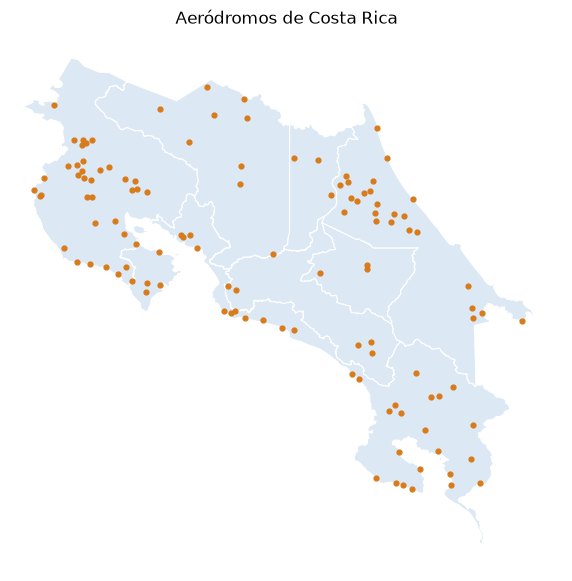

In [10]:
# Límites de la parte continental de Costa Rica, en metros de CRTM05
XLIM_CR = (280_000, 680_000)
YLIM_CR = (870_000, 1_260_000)

# Aeródromos sobre las provincias
fig, ax = plt.subplots(figsize=(9, 7))

provincias.plot(ax=ax, color="#DCE9F5", edgecolor="white", linewidth=0.8)
aerodromos.plot(ax=ax, color=NARANJA, markersize=12)

ax.set_xlim(*XLIM_CR)
ax.set_ylim(*YLIM_CR)
ax.set_title("Aeródromos de Costa Rica")
ax.set_axis_off()

plt.show()

Las dos capas se superponen correctamente porque están en el **mismo SRC**. Qué pasa cuando no es así se muestra en la clínica de errores.

*Ejercicios de esta sección: 2, en la sección de ejercicios al final del cuaderno.*

## Sistemas de referencia de coordenadas

El SRC de una capa se consulta en `crs` y se cambia, **reproyectando** todas sus geometrías, con `to_crs()`, que recibe un código EPSG y retorna una capa nueva. Los cantones en WGS84, el SRC de los mapas web y de los GPS:

In [11]:
# Reproyección a WGS84 (EPSG:4326)
cantones_wgs84 = cantones.to_crs(4326)

print(cantones_wgs84.crs)
print("Extensión en CRTM05 (metros):", cantones.total_bounds.round(0))
print("Extensión en WGS84 (grados): ", cantones_wgs84.total_bounds.round(2))

EPSG:4326
Extensión en CRTM05 (metros): [ 156147.  608899.  658877. 1241118.]
Extensión en WGS84 (grados):  [-87.1    5.5  -82.55  11.22]


`total_bounds` retorna la extensión de la capa como `[xmin, ymin, xmax, ymax]`. Los mismos cantones, en metros desde el origen de CRTM05 y en grados de longitud y latitud. La forma del país también cambia un poco, como se vio en la figura 4 de la lección anterior.

La consecuencia práctica más importante del SRC es la **medición**. El área de una geometría se calcula con `area`, en las unidades al cuadrado del SRC: metros cuadrados en CRTM05, grados cuadrados (sin sentido) en WGS84. La columna de área en km²:

In [12]:
# Área de cada cantón en km², calculada a partir de la geometría (CRTM05: metros)
cantones["area_km2_ign"] = cantones.area / 1_000_000

cantones[["canton", "area_km2_ign"]].sort_values("area_km2_ign", ascending=False).head()

,canton,area_km2_ign
29,San Carlos,3352.280097
79,Talamanca,2793.205082
67,Buenos Aires,2382.633905
77,Pococí,2188.657837
53,Sarapiquí,2143.256830


San Carlos, Talamanca y Buenos Aires: los mismos tres cantones más extensos que mostraba la columna `area_km2` del INEC en la serie *pandas*. ¿Coinciden las cifras? Para compararlas hay que unir las dos fuentes.

*Ejercicios de esta sección: 3 y 4, en la sección de ejercicios al final del cuaderno.*

## Unión con datos tabulares

Las capas del IGN traen la geometría y poco más; las cifras de población están en los CSV del INEC. Como los códigos de cantón coinciden en ambas fuentes, se unen con `merge()`, exactamente como en la [parte II](https://gf0657-programacionsig.github.io/2026-ii/pandas-agrupacion-uniones/) de la serie *pandas*. El resultado es un GeoDataFrame **siempre que el GeoDataFrame esté a la izquierda**, es decir, que sea el objeto sobre el que se llama a `merge()`:

In [13]:
# Datos del INEC por cantón
inec = pd.read_csv(DATOS_INEC + "/cantones-2022.csv")

# Unión por código de cantón; el GeoDataFrame va a la izquierda para conservar la geometría.
# Las columnas repetidas (provincia, canton) reciben los sufijos _ign e _inec.
cantones_inec = cantones.merge(inec, on="codigo_canton", how="left", suffixes=("_ign", "_inec"))

print(type(cantones_inec))
print(cantones_inec.shape)
cantones_inec[["codigo_canton", "canton_ign", "canton_inec", "poblacion", "area_km2_ign", "area_km2", "densidad"]].head()

<class 'geopandas.geodataframe.GeoDataFrame'>
(82, 21)


,codigo_canton,canton_ign,canton_inec,poblacion,area_km2_ign,area_km2,densidad
0,101,San José,San José,352381,44.718369,44.62,7897.4
1,102,Escazú,Escazú,71500,34.607010,34.53,2070.7
2,103,Desamparados,Desamparados,223226,119.293504,118.89,1877.6
3,104,Puriscal,Puriscal,38525,554.858434,555.04,69.4
4,105,Tarrazú,Tarrazú,17810,291.076607,291.27,61.1


Como siempre, se verifica la unión: ¿quedó algún cantón sin datos del INEC? ¿Coinciden los nombres?

In [14]:
# Cantones sin pareja en el INEC (debería ser 0) y nombres que no coinciden
print("Sin población:", cantones_inec["poblacion"].isna().sum())

cantones_inec[cantones_inec["canton_ign"] != cantones_inec["canton_inec"]][["codigo_canton", "canton_ign", "canton_inec"]]

Sin población: 0


,codigo_canton,canton_ign,canton_inec
10,111,Vázquez de Coronado,Vásquez de Coronado
19,120,León Cortés Castro,León Cortés


Los 82 cantones tienen pareja, pero dos nombres difieren: el IGN escribe "Vázquez de Coronado" y "León Cortés Castro" donde el INEC escribe "Vásquez de Coronado" y "León Cortés". Es el mismo problema del ejercicio de unión por nombre de la parte II, y la misma lección: **unir por código, no por nombre**. Ahora sí, las áreas:

In [15]:
# Diferencia entre el área calculada de la geometría y la publicada por el INEC
cantones_inec["dif_area"] = cantones_inec["area_km2_ign"] - cantones_inec["area_km2"]

cantones_inec[["canton_ign", "area_km2_ign", "area_km2", "dif_area"]].sort_values("dif_area", key=abs, ascending=False).head()

,canton_ign,area_km2_ign,area_km2,dif_area
65,Puntarenas,1840.607491,1816.86,23.747491
71,Golfito,1754.108678,1752.75,1.358678
75,Garabito,317.268397,316.01,1.258397
63,La Cruz,1386.591314,1385.40,1.191314
56,Santa Cruz,1321.807392,1320.80,1.007392


Las áreas coinciden (las diferencias de hasta 1 km² en algunos cantones costeros se deben a que las geometrías de la capa del curso están simplificadas), con una excepción: Puntarenas, con unos 24 km² de más en la geometría. Es la **Isla del Coco**, que pertenece al cantón, está en la capa del IGN y no está en las cifras del INEC. Un buen ejemplo de por qué conviene verificar los datos aunque provengan de fuentes oficiales.

*Ejercicios de esta sección: 4 y 5, en la sección de ejercicios al final del cuaderno.*

## Mapas de coropletas

Un **mapa de coropletas** colorea cada polígono según el valor de una variable. En geopandas basta con indicar la columna en `plot()`; `legend=True` agrega la barra de color y `cmap` elige la paleta (las de matplotlib: `"YlOrRd"`, `"Blues"`, `"viridis"`...). La densidad de población:

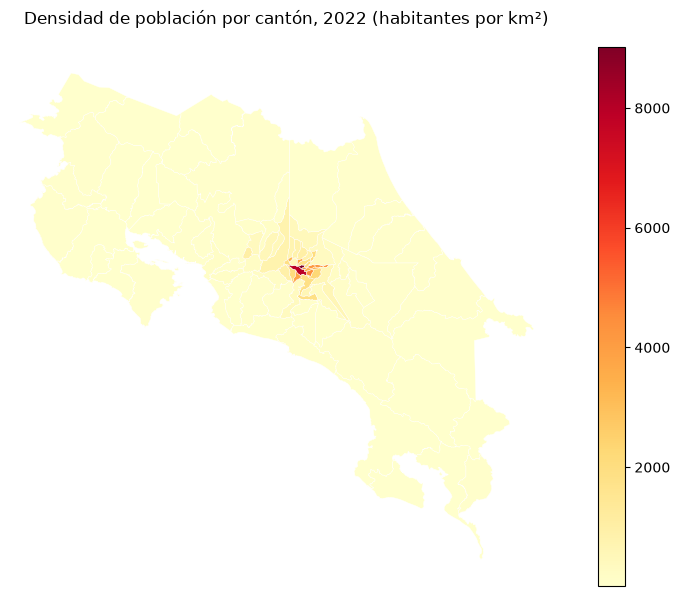

In [16]:
# Densidad de población por cantón: primer intento
fig, ax = plt.subplots(figsize=(9, 7))

cantones_inec.plot(ax=ax, column="densidad", cmap="YlOrRd", edgecolor="white", linewidth=0.3, legend=True)

ax.set_xlim(*XLIM_CR)
ax.set_ylim(*YLIM_CR)
ax.set_title("Densidad de población por cantón, 2022 (habitantes por km²)")
ax.set_axis_off()

plt.show()

El mapa es casi todo amarillo: unos pocos cantones del área metropolitana, con densidades de miles de habitantes por km², estiran la escala y el resto del país queda indistinguible. Es la misma asimetría que en la parte III obligó a usar una escala logarítmica en el histograma y en el gráfico de dispersión, y la solución es la misma: `norm=LogNorm()` aplica la escala logarítmica al color. Además, `legend_kwds` ajusta la leyenda (aquí, su título y su tamaño):

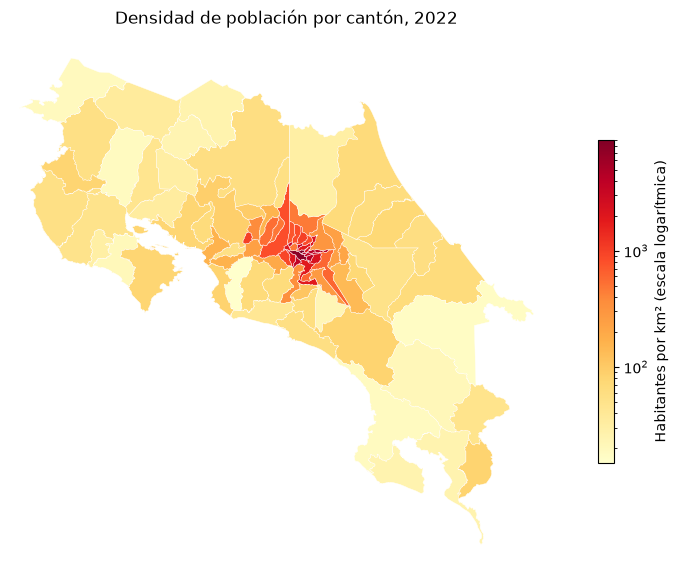

In [17]:
# Densidad de población por cantón, con escala logarítmica de color
fig, ax = plt.subplots(figsize=(9, 7))

cantones_inec.plot(
    ax=ax, column="densidad", cmap="YlOrRd", edgecolor="white", linewidth=0.3,
    norm=LogNorm(vmin=cantones_inec["densidad"].min(), vmax=cantones_inec["densidad"].max()),
    legend=True, legend_kwds={"label": "Habitantes por km² (escala logarítmica)", "shrink": 0.6}
)

ax.set_xlim(*XLIM_CR)
ax.set_ylim(*YLIM_CR)
ax.set_title("Densidad de población por cantón, 2022")
ax.set_axis_off()

plt.show()

Ahora se lee el gradiente completo: el centro del país muy denso, las llanuras del norte y del Caribe y la península de Osa poco pobladas. Para una variable con un valor central significativo, como la relación hombre-mujer del INEC (hombres por cada cien mujeres: 100 significa igual número de ambos), lo adecuado es una paleta **divergente** (`"RdBu"`, `"PiYG"`, `"BrBG"`) centrada en ese valor, con `matplotlib.colors.TwoSlopeNorm(vcenter=100)`; eso se practica en los ejercicios.

### Clasificación

La alternativa a la escala continua es **clasificar** los valores en pocas clases, cada una con un color, como hacen los SIG de escritorio. El argumento `scheme` lo hace con la biblioteca mapclassify: `"Quantiles"` pone el mismo número de cantones en cada clase, `"NaturalBreaks"` busca los cortes naturales de la distribución y `"EqualInterval"` usa intervalos iguales; `k` es el número de clases. Las clases se listan en la leyenda, que al ser discreta se coloca con `legend_kwds` como una leyenda normal de matplotlib:

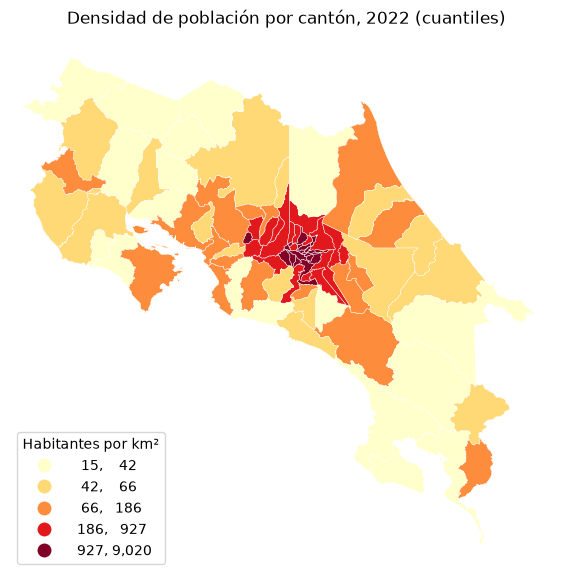

In [18]:
# Densidad de población clasificada en cinco cuantiles (requiere mapclassify)
fig, ax = plt.subplots(figsize=(9, 7))

cantones_inec.plot(
    ax=ax, column="densidad", cmap="YlOrRd", edgecolor="white", linewidth=0.3,
    scheme="Quantiles", k=5,
    legend=True, legend_kwds={"title": "Habitantes por km²", "loc": "lower left", "fmt": "{:,.0f}"}
)

ax.set_xlim(*XLIM_CR)
ax.set_ylim(*YLIM_CR)
ax.set_title("Densidad de población por cantón, 2022 (cuantiles)")
ax.set_axis_off()

plt.show()

Cada clase tiene 16 o 17 cantones, y los límites de las clases (42, 66, 186 y 927 habitantes por km²) resumen la distribución: la mitad de los cantones tiene menos de 66 habitantes por km². La clasificación simplifica la lectura a costa de ocultar las diferencias dentro de cada clase; el método elegido cambia el mapa, por lo que debe indicarse en el título o en la leyenda.

*Ejercicios de esta sección: 5 y 6, en la sección de ejercicios al final del cuaderno.*

## Mapas interactivos

`explore()` produce un **mapa interactivo** con folium, la biblioteca de mapas web de la semana 12, con los mismos argumentos principales de `plot()` (`column`, `cmap`, `legend`). El mapa se puede desplazar y acercar, y al pasar el cursor por un polígono aparecen sus atributos. geopandas reproyecta la capa a WGS84 automáticamente, cualquiera que sea su SRC. Los argumentos más útiles: `tooltip`, las columnas que se muestran al pasar el cursor; `popup`, las que se muestran al hacer clic; `tiles`, el **mapa base** (`"OpenStreetMap"`, `"CartoDB positron"`, `"CartoDB dark_matter"`); y `style_kwds`, el estilo de los polígonos:

In [19]:
# Densidad de población por cantón, en un mapa interactivo
mapa = cantones_inec.explore(
    column="densidad",
    cmap="YlOrRd",
    tooltip=["canton_inec", "provincia_inec", "poblacion", "densidad"],
    popup=True,  # todas las columnas, al hacer clic
    tiles="CartoDB positron",
    style_kwds={"color": "white", "weight": 0.5},
    legend_kwds={"caption": "Habitantes por km²"},
    location=[9.7, -84.2], zoom_start=8  # centro y acercamiento iniciales: sin ellos, la Isla del Coco aleja el mapa
)

mapa

Como en el primer mapa estático, la escala de color continua queda dominada por los cantones metropolitanos; `scheme="Quantiles"` y `k` funcionan también aquí (con mapclassify). Para superponer capas, la segunda llamada a `explore()` recibe el mapa anterior en el argumento `m`:

In [20]:
# Aeródromos sobre los cantones, en un mapa interactivo
mapa = cantones.explore(
    tooltip=["canton", "provincia"],
    tiles="CartoDB positron",
    color="#DCE9F5",
    style_kwds={"color": "white", "weight": 0.5, "fillOpacity": 0.7},
    location=[9.7, -84.2], zoom_start=8
)

aerodromos.explore(m=mapa, color=NARANJA, marker_kwds={"radius": 4}, tooltip="nombre")

mapa

La tabla 1 resume los argumentos de los dos métodos de mapas.

<figure style="text-align: center; margin: 20px 0;">
    <figcaption><strong>Tabla 1</strong>. Argumentos más usados de <code>plot()</code> y <code>explore()</code>. Fuente: elaboración propia con base en GeoPandas developers (s. f.-b).</figcaption>
    <table class="table table-bordered table-striped" style="margin: 0 auto;">
    <thead>
      <tr><th>Propósito</th><th><code>plot()</code> (matplotlib, estático)</th><th><code>explore()</code> (folium, interactivo)</th></tr>
    </thead>
    <tbody>
      <tr><td>Colorear por una variable</td><td><code>column</code>, <code>cmap</code>, <code>legend</code>, <code>norm</code></td><td><code>column</code>, <code>cmap</code>, <code>legend</code>, <code>vmin</code>, <code>vmax</code></td></tr>
      <tr><td>Clasificar</td><td><code>scheme</code>, <code>k</code></td><td><code>scheme</code>, <code>k</code></td></tr>
      <tr><td>Color y borde fijos</td><td><code>color</code>, <code>edgecolor</code>, <code>linewidth</code>, <code>alpha</code></td><td><code>color</code>, <code>style_kwds</code> (<code>color</code>, <code>weight</code>, <code>fillOpacity</code>)</td></tr>
      <tr><td>Puntos</td><td><code>markersize</code>, <code>marker</code></td><td><code>marker_kwds</code> (<code>radius</code>)</td></tr>
      <tr><td>Superponer capas</td><td><code>ax=ax</code></td><td><code>m=mapa</code></td></tr>
      <tr><td>Extensión inicial</td><td><code>ax.set_xlim()</code>, <code>ax.set_ylim()</code></td><td><code>location</code>, <code>zoom_start</code></td></tr>
      <tr><td>Información de cada entidad</td><td>—</td><td><code>tooltip</code>, <code>popup</code></td></tr>
      <tr><td>Mapa base</td><td>— (ver contextily)</td><td><code>tiles</code></td></tr>
      <tr><td>Leyenda</td><td><code>legend_kwds</code> (<code>label</code>, <code>shrink</code>, <code>title</code>, <code>loc</code>)</td><td><code>legend_kwds</code> (<code>caption</code>)</td></tr>
    </tbody>
    </table>
</figure>

*Ejercicios de esta sección: 7, en la sección de ejercicios al final del cuaderno.*

## De una tabla con coordenadas a un GeoDataFrame

Los datos de puntos rara vez llegan como capa geoespacial: lo usual es un CSV con dos columnas de coordenadas, como los registros de GBIF de la sección I o los datos que cada estudiante recopile para su tarea 3. Convertirlo en GeoDataFrame requiere dos cosas: construir los puntos a partir de las coordenadas, con `gpd.points_from_xy()`, y declarar el **SRC en que están esas coordenadas**, casi siempre WGS84. Para ilustrar el proceso de ida y vuelta, los aeródromos se convierten primero en una tabla con longitud y latitud:

In [21]:
# De GeoDataFrame a tabla: las coordenadas x e y de los puntos, en WGS84
aerodromos_wgs84 = aerodromos.to_crs(4326)

tabla = pd.DataFrame({
    "nombre": aerodromos_wgs84["nombre"],
    "longitud": aerodromos_wgs84.geometry.x,
    "latitud": aerodromos_wgs84.geometry.y
})

tabla.to_csv("aerodromos.csv", index=False)
tabla.head()

,nombre,longitud,latitud
0,Aeródromo Barra de Tortuguero,-83.515381,10.569792
1,Aeródromo Barra de Colorado,-83.585641,10.769070
2,Campo de Aterrizaje,-83.354758,8.401912
3,Campo de Aterrizaje,-83.415572,8.431671
4,Campo de Aterrizaje,-83.101440,8.432708


In [22]:
# De tabla a GeoDataFrame: puntos a partir de las columnas de coordenadas, con su SRC
tabla = pd.read_csv("aerodromos.csv")

puntos = gpd.GeoDataFrame(
    tabla,
    geometry=gpd.points_from_xy(tabla["longitud"], tabla["latitud"]),
    crs=4326
)

print(type(puntos), puntos.crs.to_epsg(), puntos.geom_type.unique().tolist())
puntos.head()

<class 'geopandas.geodataframe.GeoDataFrame'> 4326 ['Point']


,nombre,longitud,latitud,geometry
0,Aeródromo Barra de Tortuguero,-83.515381,10.569792,POINT (-83.51538 10.56979)
1,Aeródromo Barra de Colorado,-83.585641,10.769070,POINT (-83.58564 10.76907)
2,Campo de Aterrizaje,-83.354758,8.401912,POINT (-83.35476 8.40191)
3,Campo de Aterrizaje,-83.415572,8.431671,POINT (-83.41557 8.43167)
4,Campo de Aterrizaje,-83.101440,8.432708,POINT (-83.10144 8.43271)


Dos detalles que causan errores frecuentes. El orden de los argumentos de `points_from_xy()` es **x, y**, es decir, **longitud, latitud**, al revés del "latitud, longitud" con que suelen escribirse las coordenadas. Y si se omite `crs`, el GeoDataFrame queda sin SRC: los mapas se dibujan, pero `to_crs()` falla y las capas no se pueden combinar con otras.

*Ejercicios de esta sección: 8, en la sección de ejercicios al final del cuaderno.*

## Guardar una capa

`to_file()` escribe un GeoDataFrame en el formato que indique la extensión o el argumento `driver`. GeoPackage es la opción recomendada; GeoJSON es útil para la web (y conviene guardarlo en WGS84, como exige su especificación):

In [23]:
# Los cantones de Heredia, con los datos del INEC, en GeoPackage y en GeoJSON
heredia_inec = cantones_inec[cantones_inec["provincia_ign"] == "Heredia"]

heredia_inec.to_file("cantones-heredia.gpkg", driver="GPKG")
heredia_inec.to_crs(4326).to_file("cantones-heredia.geojson", driver="GeoJSON")

# Comprobación: se vuelve a leer el GeoPackage
gpd.read_file("cantones-heredia.gpkg").shape

(10, 22)

*Ejercicios de esta sección: 9, en la sección de ejercicios al final del cuaderno.*

## Clínica de errores

Los tres errores más frecuentes al empezar con geopandas, provocados a propósito. El primero no da ningún mensaje:

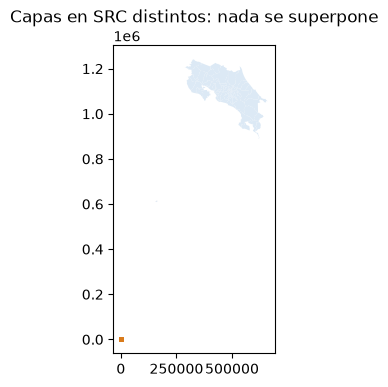

In [24]:
# Error silencioso: dos capas en SRC distintos en el mismo mapa.
# Los aeródromos en WGS84 (grados) sobre los cantones en CRTM05 (metros): los puntos
# quedan todos en una esquina, a la escala de los grados, y los cantones no se ven.
fig, ax = plt.subplots(figsize=(6, 4))
cantones.plot(ax=ax, color="#DCE9F5")
aerodromos_wgs84.plot(ax=ax, color=NARANJA, markersize=5)
ax.set_title("Capas en SRC distintos: nada se superpone")
plt.show()

In [25]:
# UserWarning: "Geometry is in a geographic CRS. Results from 'area' are likely incorrect."
# El área en WGS84 se calcula en grados cuadrados; hay que reproyectar antes (to_crs(5367))
cantones_wgs84.area.head(3)

/tmp/ipykernel_1295583/2186917603.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cantones_wgs84.area.head(3)


0    0.003688
1    0.002854
2    0.009834
dtype: float64

In [26]:
# AttributeError: 'DataFrame' object has no attribute 'explore'
# pd.merge() con el DataFrame a la izquierda retorna un DataFrame: la geometría queda como una columna
# cualquiera y se pierden los métodos geoespaciales. Debe ser cantones.merge(inec, ...).
union = pd.merge(inec, cantones, on="codigo_canton")
print(type(union))
union.explore()

<class 'pandas.DataFrame'>


AttributeError: 'DataFrame' object has no attribute 'explore'

## Asistentes de IA para generar mapas

Las pautas de las partes II y III de la serie *pandas* aplican: describir el GeoDataFrame en el contexto (columnas y, ahora, también el SRC), pedir el patrón del curso y verificar el resultado. Para los mapas hay tres comprobaciones específicas: que el código no mezcle SRC (todas las capas en el mismo, y reproyectadas antes de medir), que la escala de color sea adecuada para la distribución de la variable (logarítmica o clasificada si es asimétrica, divergente si tiene un valor central) y que la leyenda tenga unidades. Un prompt de ejemplo:

> Actúe como asistente de visualización de datos geoespaciales con geopandas y matplotlib **(rol)**. Tengo un GeoDataFrame llamado `cantones_inec`, con un polígono por cantón de Costa Rica en el SRC EPSG:5367 y las columnas `canton_inec` (texto), `provincia_inec` (texto), `poblacion` (entero) y `relacion_hombre_mujer` (decimal: hombres por cada cien mujeres, entre 82 y 121) **(contexto)**. Escriba el código de un mapa de coropletas de la relación hombre-mujer, con una paleta divergente centrada en 100, barra de color con etiqueta en español, título, bordes blancos, sin ejes y con los límites de los ejes en las constantes `XLIM_CR` y `YLIM_CR` **(tarea)**. Use el patrón `fig, ax = plt.subplots()` y `cantones_inec.plot(ax=ax, ...)`, y termine con `plt.show()` **(formato)**.

## Resumen

- geopandas extiende pandas con la **GeoSeries** (columna de geometrías de shapely) y el **GeoDataFrame** (DataFrame con una columna de geometría activa); todas las operaciones de pandas funcionan y conservan la geometría si el GeoDataFrame está a la izquierda en `merge()`.
- `gpd.read_file()` lee cualquier formato vectorial (desde rutas o URL) y `to_file()` escribe, preferiblemente en **GeoPackage**. `crs`, `geom_type`, `geometry` y `total_bounds` describen la parte geoespacial.
- `to_crs(codigo)` **reproyecta**. Para medir (`area`, `length`) la capa debe estar en un SRC proyectado, en Costa Rica **CRTM05 (EPSG:5367)**; para superponer capas, todas deben estar en el mismo SRC.
- `plot()` dibuja mapas estáticos con matplotlib, superponiendo capas con `ax`; con `column` produce **coropletas**, cuya escala de color se ajusta con `norm=LogNorm()` para variables asimétricas, con paletas divergentes y `TwoSlopeNorm` para variables con un valor central, o con `scheme` y `k` para **clasificar** (mapclassify). La Isla del Coco obliga a fijar la extensión de los mapas nacionales (`set_xlim()`, `set_ylim()`; `location` y `zoom_start` en `explore()`).
- `explore()` produce mapas **interactivos** con folium, con `tooltip`, `popup`, `tiles` y `m` para superponer.
- Una tabla con coordenadas se convierte en GeoDataFrame con `gpd.points_from_xy(longitud, latitud)` y `crs=4326`: en ese orden y con el SRC declarado.

## Ejercicios

Los ejercicios se agrupan según la sección del cuaderno a la que corresponden; se recomienda realizarlos al concluir la sección respectiva. Resuélvalos en este mismo cuaderno (en su copia de Colab o local), después de ejecutar las celdas de las secciones anteriores. Varios incluyen una **celda de verificación** que examina el objeto creado: para que funcione, nombre los objetos como se indica en el enunciado y ejecute la celda tal cual después de resolver el ejercicio (en la versión publicada muestra un recordatorio, porque los ejercicios no están resueltos). Las [soluciones de estos ejercicios](https://gf0657-programacionsig.github.io/2026-ii/soluciones-geopandas-datos-vectoriales) se publican después de la clase correspondiente.

### Carga y exploración

1. Cargue en `distritos_inec` el CSV de distritos del INEC (`DATOS_INEC + "/distritos-2022.csv"`) con pandas, e intente convertirlo en GeoDataFrame con `gpd.GeoDataFrame(distritos_inec)`. Observe qué sucede al llamar a `plot()` y explique, en una celda de texto, por qué un GeoDataFrame sin columna de geometría no sirve de mucho y qué haría falta para mapear los distritos. Luego, con `cantones`, imprima cuántos cantones tiene cada provincia (con `value_counts()`) y guarde el resultado en `cantones_por_provincia`.

In [27]:
# Celda de verificación del ejercicio 1: ejecútela tal cual
try:
    assert len(cantones_por_provincia) == 7, "Deben ser 7 provincias"
    assert cantones_por_provincia.sum() == 82, "Deben sumar 82 cantones"
    assert cantones_por_provincia.idxmax() == "San José", "San José es la provincia con más cantones"
    print("Ejercicio 1: ¡correcto!")
except NameError:
    print("Aún no se ha definido cantones_por_provincia (ejercicio 1).")

Aún no se ha definido cantones_por_provincia (ejercicio 1).


2. Cree en `guanacaste` el GeoDataFrame con los cantones de Guanacaste y dibuje, en `ax_2`, un mapa estático con los cantones en color claro, los límites en blanco, el límite de la provincia encima en azul, título y sin ejes. ¿Cuántos cantones tiene la provincia?

In [28]:
# Celda de verificación del ejercicio 2: ejecútela tal cual
try:
    assert isinstance(guanacaste, gpd.GeoDataFrame), "guanacaste debe ser un GeoDataFrame"
    assert len(guanacaste) == 11, "Guanacaste tiene 11 cantones"
    assert ax_2.get_title(), "Falta el título"
    assert not ax_2.axison, "Los ejes deben estar ocultos (set_axis_off())"
    print("Ejercicio 2: ¡correcto!")
except NameError:
    print("Aún no se han definido guanacaste y ax_2 (ejercicio 2).")

Aún no se han definido guanacaste y ax_2 (ejercicio 2).


### Sistemas de referencia de coordenadas y uniones

3. Reproyecte `aerodromos` a WGS84 en `aerodromos_4326` y a la zona UTM 17 norte (EPSG:32617) en `aerodromos_utm`. Imprima las coordenadas del primer aeródromo en los tres SRC (`geometry.x` y `geometry.y`) y explique en una celda de texto por qué los tres pares de números representan el mismo lugar.

In [29]:
# Celda de verificación del ejercicio 3: ejecútela tal cual
try:
    assert aerodromos_4326.crs.to_epsg() == 4326, "aerodromos_4326 debe estar en EPSG:4326"
    assert aerodromos_utm.crs.to_epsg() == 32617, "aerodromos_utm debe estar en EPSG:32617"
    assert len(aerodromos_4326) == len(aerodromos) == len(aerodromos_utm), "La reproyección no cambia el número de filas"
    print("Ejercicio 3: ¡correcto!")
except NameError:
    print("Aún no se han definido aerodromos_4326 y aerodromos_utm (ejercicio 3).")

Aún no se han definido aerodromos_4326 y aerodromos_utm (ejercicio 3).


4. Agregue a `provincias` la columna `area_km2_ign` con el área calculada de la geometría, una las provincias con el CSV `provincias-2022.csv` del INEC en `provincias_inec` (por `codigo_provincia`, con el GeoDataFrame a la izquierda) y compare las dos áreas. ¿En cuál provincia está la diferencia y a qué se debe?

In [30]:
# Celda de verificación del ejercicio 4: ejecútela tal cual
try:
    assert isinstance(provincias_inec, gpd.GeoDataFrame), "provincias_inec debe ser un GeoDataFrame (¿el GeoDataFrame quedó a la izquierda?)"
    assert len(provincias_inec) == 7 and "poblacion" in provincias_inec.columns, "Deben ser 7 provincias con los datos del INEC"
    assert abs(provincias_inec["area_km2_ign"].sum() - 51_177) < 50, "El área total del país debe rondar los 51 100 km²"
    print("Ejercicio 4: ¡correcto!")
except NameError:
    print("Aún no se ha definido provincias_inec (ejercicio 4).")

Aún no se ha definido provincias_inec (ejercicio 4).


### Mapas de coropletas

5. En `ax_5`, dibuje un mapa de coropletas de la **población** de las provincias (`provincias_inec`), con la paleta `"Blues"`, barra de color con etiqueta, el nombre de cada provincia como texto sobre su polígono (pista: `representative_point()` da un punto dentro de cada polígono, y `ax.annotate()` o `ax.text()` escriben en él), título y los límites de la parte continental.

In [31]:
# Celda de verificación del ejercicio 5: ejecútela tal cual
try:
    assert ax_5.get_title(), "Falta el título"
    assert len(ax_5.texts) == 7, "Debe haber un texto por provincia (7)"
    assert len(ax_5.figure.axes) >= 2, "Falta la barra de color (legend=True)"
    print("Ejercicio 5: ¡correcto!")
except NameError:
    print("Aún no se ha definido ax_5 (ejercicio 5).")

Aún no se ha definido ax_5 (ejercicio 5).


6. En `ax_6`, dibuje un mapa de coropletas de la relación hombre-mujer por cantón (`relacion_hombre_mujer` de `cantones_inec`), con una paleta divergente centrada en 100 (con `norm=TwoSlopeNorm(vcenter=100, vmin=80, vmax=120)`, de `matplotlib.colors`), barra de color con etiqueta, título y los límites de la parte continental. ¿Dónde hay más mujeres que hombres y dónde más hombres que mujeres? Interprete el patrón geográfico en una celda de texto.

In [32]:
# Celda de verificación del ejercicio 6: ejecútela tal cual
try:
    assert ax_6.get_title(), "Falta el título"
    assert len(ax_6.collections) >= 1, "El mapa debe tener polígonos dibujados"
    colorbar = ax_6.figure.axes[-1]
    assert colorbar is not ax_6 and colorbar.get_ylabel(), "Falta la barra de color con etiqueta"
    print("Ejercicio 6: ¡correcto!")
except NameError:
    print("Aún no se ha definido ax_6 (ejercicio 6).")

Aún no se ha definido ax_6 (ejercicio 6).


### Mapas interactivos y puntos

7. Cree en `mapa_7` un mapa interactivo de `cantones_inec` clasificado en cinco clases por **cuantiles** de la relación hombre-mujer, con la paleta divergente `"RdBu"`, el nombre del cantón, la provincia y la relación en la etiqueta emergente, el mapa base `"CartoDB positron"`, bordes blancos y el centro y acercamiento iniciales del cuaderno. Si trabaja en Colab, instale antes mapclassify. Compare el mapa con el del ejercicio 6: ¿qué muestra la clasificación que la escala continua no, y viceversa?

In [33]:
# Celda de verificación del ejercicio 7: ejecútela tal cual
try:
    import folium
    assert isinstance(mapa_7, folium.Map), "mapa_7 debe ser un mapa de folium (resultado de explore())"
    print("Ejercicio 7: ¡correcto!")
except NameError:
    print("Aún no se ha definido mapa_7 (ejercicio 7).")

Aún no se ha definido mapa_7 (ejercicio 7).


8. Construya a mano un DataFrame con tres lugares que conozca (por ejemplo, su casa, la Escuela de Geografía y un sitio de interés), con columnas `nombre`, `longitud` y `latitud` obtenidas de Google Maps u OpenStreetMap, y conviértalo en el GeoDataFrame `lugares` con el SRC correcto. Muéstrelo en un mapa interactivo sobre los cantones y verifique que los puntos caen donde deben. Luego reproyecte `lugares` a CRTM05 y compare las coordenadas resultantes con las de un aeródromo cercano.

In [34]:
# Celda de verificación del ejercicio 8: ejecútela tal cual
try:
    assert isinstance(lugares, gpd.GeoDataFrame) and len(lugares) >= 3, "lugares debe ser un GeoDataFrame con al menos 3 filas"
    assert lugares.crs is not None and lugares.crs.to_epsg() == 4326, "Las coordenadas de Google Maps/OSM están en WGS84: crs=4326"
    assert (lugares.geometry.x < 0).all() and (lugares.geometry.y > 0).all(), "¿Longitud y latitud en el orden correcto? En Costa Rica x es negativa e y positiva"
    print("Ejercicio 8: ¡correcto!")
except NameError:
    print("Aún no se ha definido lugares (ejercicio 8).")

Aún no se ha definido lugares (ejercicio 8).


### Guardar, predecir y asistentes

9. Guarde `guanacaste` con los datos del INEC (únalos primero) en un GeoPackage `cantones-guanacaste.gpkg` y vuelva a leerlo en `guanacaste_leido`. Compruebe que el SRC y el número de filas se conservaron.

In [35]:
# Celda de verificación del ejercicio 9: ejecútela tal cual
try:
    import os
    assert len(guanacaste_leido) == 11 and guanacaste_leido.crs == guanacaste.crs, "El archivo leído debe tener 11 cantones y el mismo SRC"
    assert os.path.exists("cantones-guanacaste.gpkg"), "No se encuentra el archivo cantones-guanacaste.gpkg"
    print("Ejercicio 9: ¡correcto!")
except NameError:
    print("Aún no se ha definido guanacaste_leido (ejercicio 9).")

Aún no se ha definido guanacaste_leido (ejercicio 9).


10. **Prediga antes de ejecutar**: ¿qué dibuja el siguiente código? ¿De qué color es cada cantón, cuántos colores hay y qué muestra la leyenda? Escriba su predicción en una celda de texto y luego ejecútelo.

```python
fig, ax = plt.subplots(figsize=(8, 6))
cantones.plot(ax=ax, column="provincia", legend=True, edgecolor="white", linewidth=0.3)
ax.set_axis_off()
plt.show()
```

<details>
<summary>Explicación (ábrala después de predecir)</summary>

Cuando `column` es una columna de **texto**, geopandas la trata como categórica: asigna un color distinto a cada valor (siete, uno por provincia, con la paleta categórica por defecto) y la leyenda es una lista de categorías, no una barra de color. Es la forma más rápida de ver a qué provincia pertenece cada cantón. Con `categorical=True` se fuerza el mismo comportamiento para una columna numérica con pocos valores, como un código.

</details>

11. Pida a un asistente de IA el código del prompt de ejemplo de la sección de asistentes (coropletas de la relación hombre-mujer) y verifíquelo: lea el código, compruebe que no mezcla SRC, que la paleta es divergente y está centrada en 100, que la leyenda tiene unidades, y compare los colores de tres cantones con sus valores en `cantones_inec`. Documente en una celda de texto el asistente, el prompt, el código y el resultado de las comprobaciones.

12. Para la tarea 3, que agrega el componente geoespacial a los datos de su tema, identifique una fuente de datos vectoriales (puntos, líneas o polígonos) relacionada con el tema de sus tareas anteriores, ya sea una capa del SNIT, un CSV con coordenadas, un GeoJSON o una capa de GBIF, Natural Earth u otra fuente. Cárguela con geopandas (o constrúyala con `points_from_xy()`), imprima su SRC, su número de filas y sus tipos de geometría, y dibújela sobre las provincias en un mapa estático. Anote en una celda de texto qué preguntas podría responder al combinarla con las capas del IGN y los datos del INEC.

## Referencias bibliográficas

GeoPandas developers. (s. f.-a). Introduction to GeoPandas. En *GeoPandas documentation*. Recuperado el 4 de octubre de 2026, de https://geopandas.org/en/stable/getting_started/introduction.html
\
\
GeoPandas developers. (s. f.-b). *GeoPandas documentation*. Recuperado el 4 de octubre de 2026, de https://geopandas.org/
\
\
Instituto Geográfico Nacional. (s. f.). *División territorial administrativa (límite provincial y límite cantonal) y aeródromos* [Conjunto de datos]. Sistema Nacional de Información Territorial. Recuperado el 4 de octubre de 2026, de https://www.snitcr.go.cr/
\
\
Instituto Nacional de Estadística y Censos. (2023). *Resultados Estimación de Población y Vivienda 2022* [Conjunto de datos]. INEC. https://admin.inec.cr/sites/default/files/2023-11/reResultadosEstimacionPoblacionVivienda2022_3.xlsx
\
\
Kaggle. (s. f.). Your first map. En *Geospatial analysis*. Kaggle Learn. Recuperado el 4 de octubre de 2026, de https://www.kaggle.com/code/alexisbcook/your-first-map
\
\
Rey, S. J., Arribas-Bel, D. y Wolf, L. J. (2023). *Geographic data science with Python*. CRC Press. https://geographicdata.science/book/